In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import CLIPProcessor, CLIPModel
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset

# from tqdm.auto import tqdm
# from tqdm import tqdm
from tqdm.notebook import tqdm
import math

#! pip install hf_xet


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [58]:
# -----------------------------
# 1. Load CLIP (image encoder only is fine)
# -----------------------------
model_name = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name, use_fast=True)
# processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Freeze CLIP parameters
model.eval()
for param in model.parameters():
    param.requires_grad = False

In [59]:
# -----------------------------
# 3. Dataset + transforms
# -----------------------------
transform = transforms.Compose([
    # transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
train_data = datasets.CIFAR10(root="./Dataset", train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root="./Dataset", train=False, download=True, transform=transform)


In [60]:
# -----------------------------
# Helper: Extract embeddings for entire dataset
# -----------------------------
def extract_clip_embeddings(dataset, batch_size=128):
    all_features = []
    all_labels = []

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    for images, labels in tqdm(loader, desc="Extracting CLIP features"):
        # Process images through CLIP preprocessor
        images = processor(images=list(images), return_tensors="pt").to(device)

        # Extract embeddings
        with torch.no_grad():
            features = model.get_image_features(**images).detach().to(device)

        # (Optional) normalize for CLIP-style cosine similarity
        # features = features / features.norm(dim=1, keepdim=True)

        all_features.append(features)
        all_labels.append(labels)
        

    all_features = torch.cat(all_features, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    return all_features, all_labels

In [61]:
# -----------------------------
# Precompute embeddings
# -----------------------------
train_data = TensorDataset(*extract_clip_embeddings(train_data, batch_size=128))
test_data  = TensorDataset(*extract_clip_embeddings(test_data,  batch_size=128))

print("Train embedding shape:", len(train_data))  # should be (50000, 512)
print("Test embedding shape:", len(test_data))    # should be (10000, 512)

Extracting CLIP features:   0%|          | 0/391 [00:00<?, ?it/s]

Extracting CLIP features:   0%|          | 0/79 [00:00<?, ?it/s]

Train embedding shape: 50000
Test embedding shape: 10000


In [62]:
# train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2, prefetch_factor=1, persistent_workers=False)
# test_loader  = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=2, prefetch_factor=1, persistent_workers=False)

In [63]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=0)

In [64]:
# -----------------------------
# 2. A simple MLP classifier
# -----------------------------
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.fc(x)
    
    def forward_inference(self, x):
        softmax = nn.Softmax(dim=1)
        return softmax(self.fc(x))

In [65]:
# CLIP image embeddings are 512d for ViT-B/32
embedding_dim = 512  # depends on the CLIP model used
classifier = MLPClassifier(embedding_dim, num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)

In [66]:
train_loss_list = []

In [67]:
num_epochs = 100
print_interval = math.ceil(num_epochs//10)

classifier.train()
# for epoch in range(num_epochs):
for epoch in tqdm(range(num_epochs), desc="Training", unit='Epoch'):  # Loop over epochs
    epoch_loss = 0
    # loop = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch+1}/{num_epochs}")

    # for embedding, target in loop:
    for embedding, target in train_loader:
        optimizer.zero_grad()
        embedding = embedding.to(device)
        target = target.to(device)

        output = classifier(embedding)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        # update tqdm bar text
        # loop.set_postfix(epoch_loss) 
        
    train_loss = epoch_loss / len(train_loader)
    train_loss_list.append(train_loss)

    if (epoch + 1) % print_interval == 0:
        print(f"Epoch {epoch+1:4} / {num_epochs:4},   Train Loss: {train_loss:8f}")
    

Training:   0%|          | 0/100 [00:00<?, ?Epoch/s]

Epoch   10 /  100,   Train Loss: 1.880757
Epoch   20 /  100,   Train Loss: 1.778459
Epoch   30 /  100,   Train Loss: 1.725277
Epoch   40 /  100,   Train Loss: 1.669387
Epoch   50 /  100,   Train Loss: 1.632980
Epoch   60 /  100,   Train Loss: 1.606441
Epoch   70 /  100,   Train Loss: 1.585145
Epoch   80 /  100,   Train Loss: 1.565227
Epoch   90 /  100,   Train Loss: 1.554075
Epoch  100 /  100,   Train Loss: 1.535952


In [38]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_over_epoch(train_metric_list, test_metric_list=None, val=False, title="", y_label="Mean Loss", figure_size=(8, 5)):
    plt.figure(figsize=figure_size)

    epochs = np.arange(1, len(train_metric_list) + 1)
    plt.plot(epochs, train_metric_list, label='Train', linewidth=2)
    if test_metric_list is not None:
        label = 'Validation' if val else 'Test' 
        plt.plot(epochs, test_metric_list, color='salmon', label=label, linewidth=2)

    plt.xlabel('Epoch')
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    # plt.tight_layout()
    plt.show()

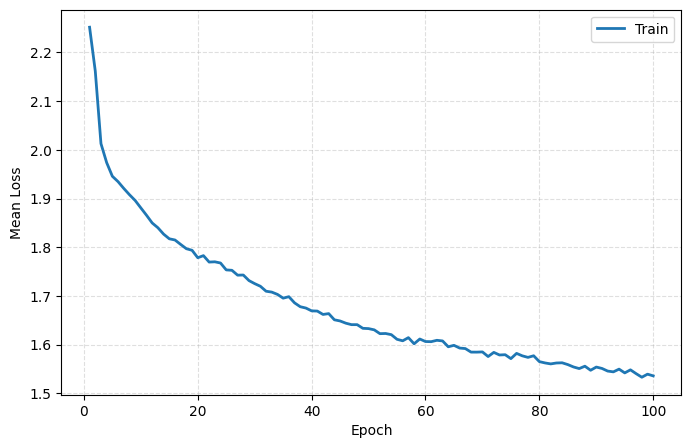

In [68]:
plot_metric_over_epoch(train_loss_list)

In [56]:
num_epochs = 100
print_interval = math.ceil(num_epochs//10)

classifier.train()
# for epoch in range(num_epochs):
for epoch in tqdm(range(num_epochs), desc="Training", unit='Epoch'):  # Loop over epochs
    epoch_loss = 0
    # loop = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch+1}/{num_epochs}")

    # for embedding, target in loop:
    for embedding, target in train_loader:
        optimizer.zero_grad()
        embedding = embedding.to(device)
        target = target.to(device)

        output = classifier(embedding)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        # update tqdm bar text
        # loop.set_postfix(epoch_loss) 
        
    train_loss = epoch_loss / len(train_loader)
    train_loss_list.append(train_loss)

    if (epoch + 1) % print_interval == 0:
        print(f"Epoch {epoch+1:4} / {num_epochs:4},   Train Loss: {train_loss:8f}")
    

Training:   0%|          | 0/100 [00:00<?, ?Epoch/s]

Epoch   10 /  100,   Train Loss: 1.909840
Epoch   20 /  100,   Train Loss: 1.834713
Epoch   30 /  100,   Train Loss: 1.766698
Epoch   40 /  100,   Train Loss: 1.720244
Epoch   50 /  100,   Train Loss: 1.666308
Epoch   60 /  100,   Train Loss: 1.636689
Epoch   70 /  100,   Train Loss: 1.613048
Epoch   80 /  100,   Train Loss: 1.591423
Epoch   90 /  100,   Train Loss: 1.576105
Epoch  100 /  100,   Train Loss: 1.566848


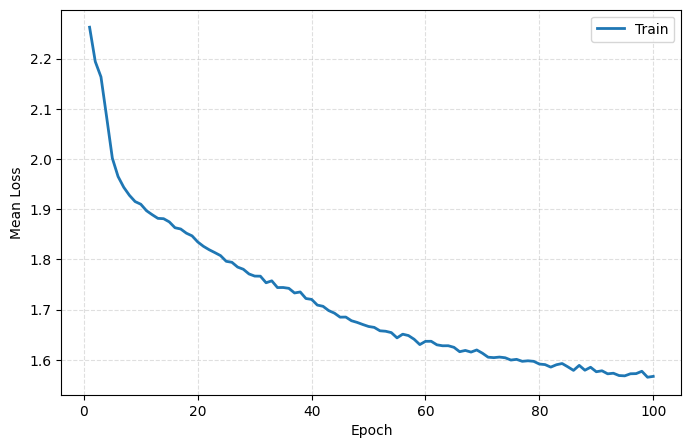

In [57]:
plot_metric_over_epoch(train_loss_list)

In [ ]:
def classify(image):
    model.eval()
    classifier.eval()
    
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        image_features = model.get_image_features(**inputs)
        # image_features /= image_features.norm(dim=1, keepdim=True)
        logits = classifier.forward_inference(image_features)
        pred = logits.argmax(dim=1).item()
    return pred


In [69]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report  # optional, pip install scikit-learn

# -----------------------------
# Evaluation
# -----------------------------
def evaluate(model, classifier, processor, dataloader, device):
    model.eval()
    classifier.eval()

    all_preds = []
    all_labels = []
    total, correct = 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            image_features = images.to(device)
            labels = labels.to(device)

            # Prepare inputs for HuggingFace CLIPProcessor
            # inputs = processor(images=images, return_tensors="pt").to(device)

            # # Extract CLIP image features
            # image_features = model.get_image_features(**inputs)  # (B, D)

            # # Normalize (important — CLIP uses cosine similarity during training)
            # image_features = image_features / image_features.norm(dim=1, keepdim=True)

            # Classifier forward
            logits = classifier(image_features)  # (B, num_classes)
            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    acc = correct / total
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Optional confusion matrix and classification report
    try:
        cm = confusion_matrix(all_labels, all_preds)
        report = classification_report(all_labels, all_preds, digits=4)
    except Exception as e:
        cm, report = None, None

    return acc, cm, report

# Example usage
test_acc, test_cm, test_report = evaluate(model, classifier, processor, test_loader, device)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
if test_cm is not None:
    print("Confusion matrix shape:", test_cm.shape)
    print(test_report)


Test Accuracy: 44.71%
Confusion matrix shape: (10, 10)
              precision    recall  f1-score   support

           0     0.5437    0.3920    0.4555      1000
           1     0.5000    0.5620    0.5292      1000
           2     0.3734    0.1430    0.2068      1000
           3     0.3168    0.3390    0.3275      1000
           4     0.3861    0.3610    0.3731      1000
           5     0.4811    0.3180    0.3829      1000
           6     0.4621    0.6710    0.5473      1000
           7     0.4742    0.4960    0.4848      1000
           8     0.4681    0.6890    0.5574      1000
           9     0.4401    0.5000    0.4682      1000

    accuracy                         0.4471     10000
   macro avg     0.4446    0.4471    0.4333     10000
weighted avg     0.4446    0.4471    0.4333     10000

